<a href="https://colab.research.google.com/github/Darri916/Darri916/blob/main/MLOM_MusicLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q librosa soundfile matplotlib seaborn scikit-learn tensorflow gdown

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import os, warnings
warnings.filterwarnings('ignore')

import librosa
import librosa.display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("Setup complete!")
print(f"TensorFlow: {tf.__version__}")

Setup complete!
TensorFlow: 2.19.0


In [ ]:
import os
import zipfile
from google.colab import files

DATASET_PATH = "/content/genres"
GENRES = ['blues', 'classical', 'country', 'disco', 'hiphop',
          'jazz', 'metal', 'pop', 'reggae', 'rock']

# Upload file
uploaded = files.upload()

# Extract
for filename in uploaded.keys():
    print(f"\n Extracting {filename}...")

    if filename.endswith('.zip'):
        with zipfile.ZipFile(filename, 'r') as zip_ref:
            zip_ref.extractall('/content/')
        print(" Extraction complete!")

# Find dataset path
possible_paths = [
    "/content/genres mini/Data/genres_original",
    "/content/Data/genres_original"
]

for path in possible_paths:
    if os.path.exists(path):
        DATASET_PATH = path
        break

# Verify

print("VERIFICATION")


if os.path.exists(DATASET_PATH):
    print(f" Dataset found: {DATASET_PATH}\n")

    total_files = 0
    for genre in GENRES:
        genre_path = os.path.join(DATASET_PATH, genre)
        if os.path.exists(genre_path):
            files_list = [f for f in os.listdir(genre_path) if f.endswith('.wav')]
            print(f" {genre:12s}: {len(files_list):3d} files")
            total_files += len(files_list)

    print(f"\n Total: {total_files} audio files")

    if total_files >= 50:
        print("\nDATASET READY!")
    else:
        print("\nLow file count")
else:
    print(" Dataset not found. Please check folder structure.")

VERIFICATION
 Dataset found: /content/genres mini/Data/genres_original

 blues       : 100 files
 classical   : 100 files
 country     : 100 files
 disco       : 100 files
 hiphop      : 100 files
 jazz        : 100 files
 metal       : 100 files
 pop         : 100 files
 reggae      : 100 files
 rock        : 100 files

 Total: 1000 audio files

DATASET READY!


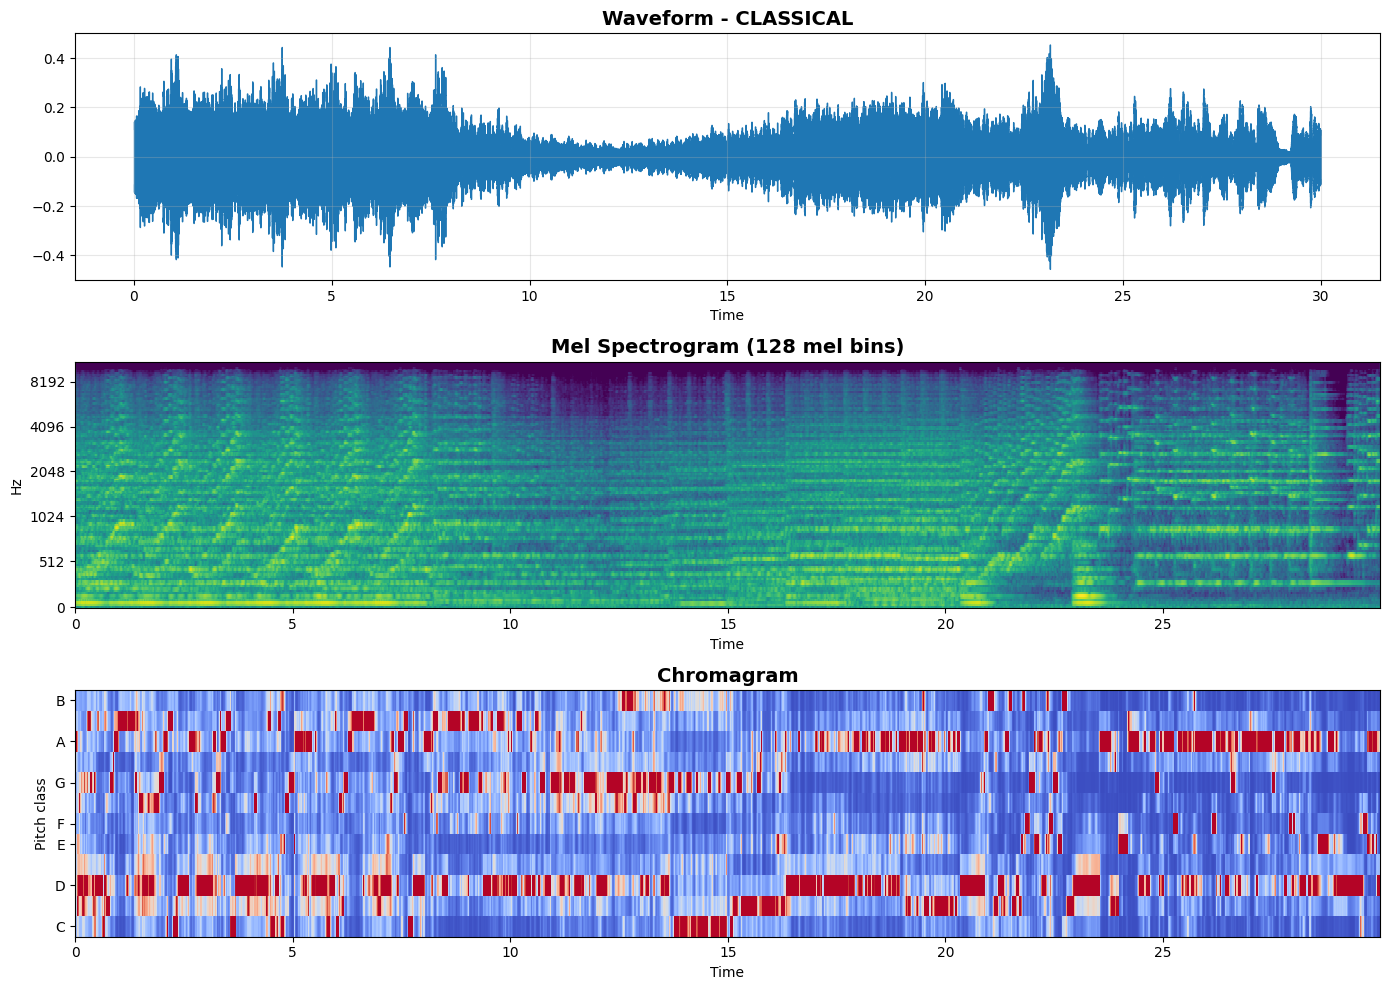

Visualized classical


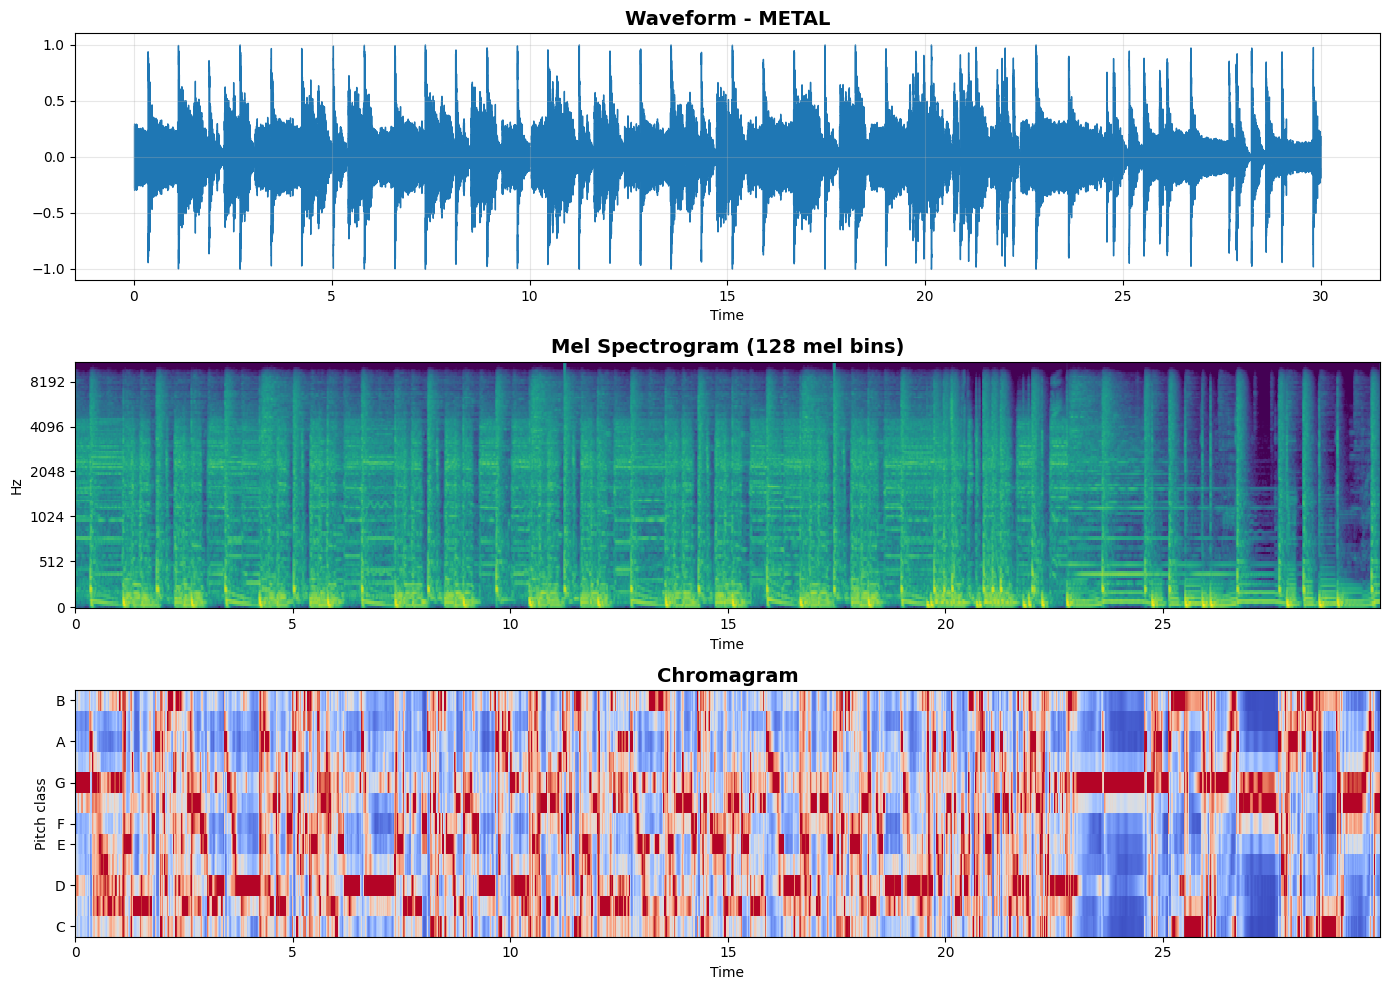

Visualized metal


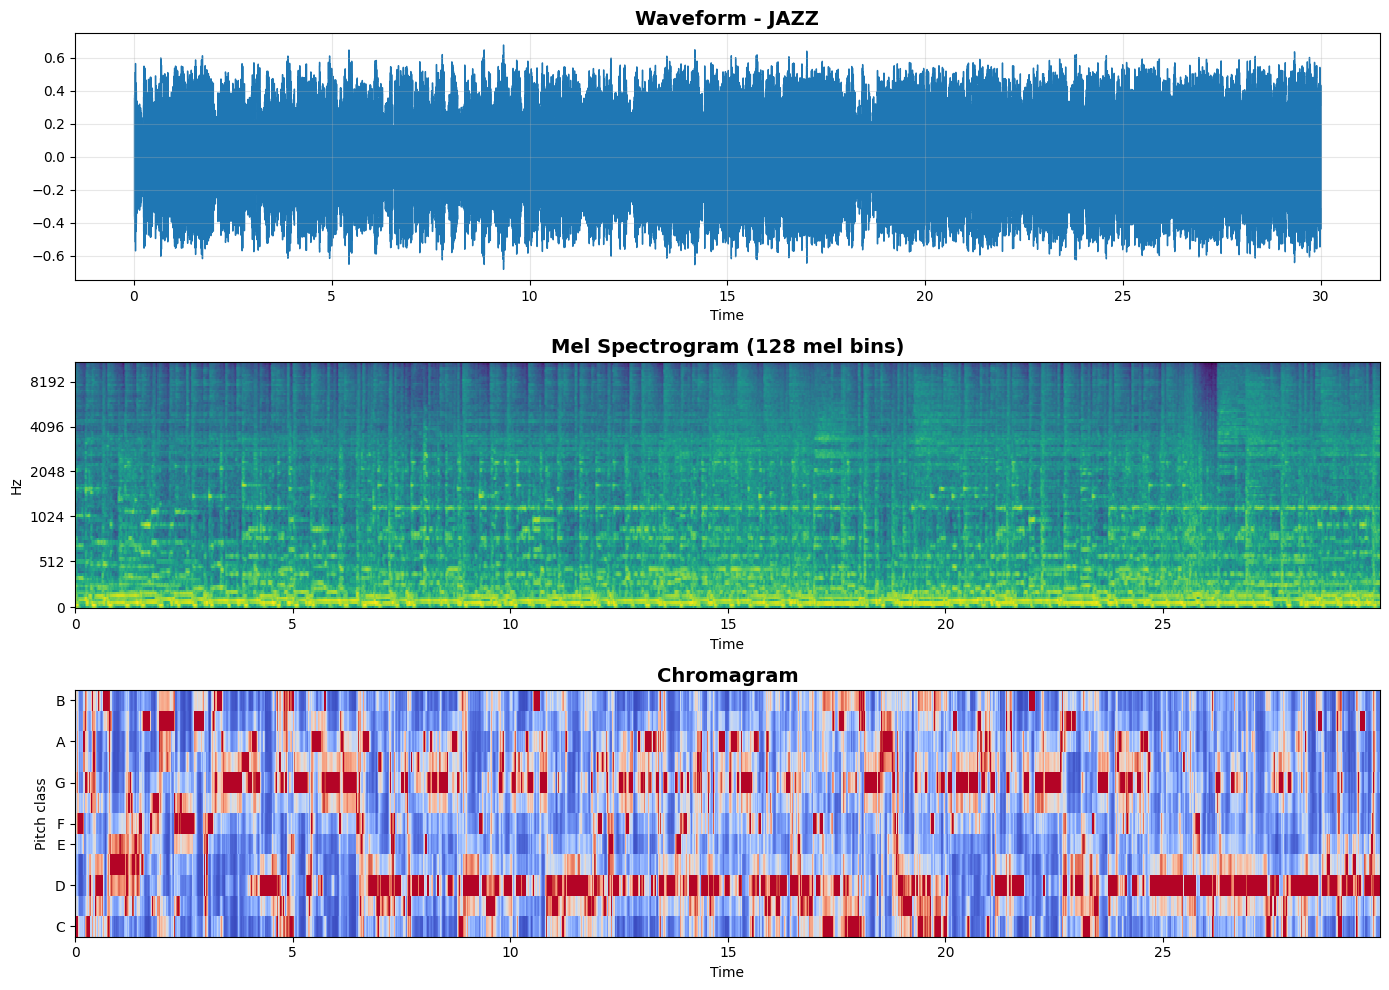

Visualized jazz


In [ ]:
def visualize_audio(genre, file_idx=0):
    genre_path = os.path.join(DATASET_PATH, genre)
    files = [f for f in os.listdir(genre_path) if f.endswith('.wav')]

    if len(files) == 0:
        print(f"No files for {genre}")
        return

    file_path = os.path.join(genre_path, files[file_idx])
    y, sr = librosa.load(file_path, duration=30, sr=22050)

    fig, axes = plt.subplots(3, 1, figsize=(14, 10))

    # Waveform
    librosa.display.waveshow(y, sr=sr, ax=axes[0])
    axes[0].set_title(f'Waveform - {genre.upper()}', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)

    # Mel Spectrogram
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    librosa.display.specshow(mel_spec_db, sr=sr, x_axis='time', y_axis='mel',
                             ax=axes[1], cmap='viridis')
    axes[1].set_title('Mel Spectrogram (128 mel bins)', fontsize=14, fontweight='bold')

    # Chroma
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    librosa.display.specshow(chroma, sr=sr, x_axis='time', y_axis='chroma',
                             ax=axes[2], cmap='coolwarm')
    axes[2].set_title('Chromagram', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()
    print(f"Visualized {genre}")

# Visualize samples
for genre in ['classical', 'metal', 'jazz']:
    visualize_audio(genre)


In [ ]:
def extract_features(file_path, duration=30, max_pad_len=650):  # Reduced from 1300
    try:
        y, sr = librosa.load(file_path, duration=duration, sr=22050, mono=True)

        # Use smaller mel spectrogram
        mel_spec = librosa.feature.melspectrogram(
            y=y, sr=sr,
            n_mels=64,  # Reduced from 128
            n_fft=2048,
            hop_length=512,
            fmax=8000
        )
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

        # Pad or truncate
        if mel_spec_db.shape[1] < max_pad_len:
            pad_width = max_pad_len - mel_spec_db.shape[1]
            mel_spec_db = np.pad(mel_spec_db, pad_width=((0, 0), (0, pad_width)), mode='constant')
        else:
            mel_spec_db = mel_spec_db[:, :max_pad_len]

        return mel_spec_db
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None


def load_dataset(dataset_path, genres, max_per_genre=100):
    features, labels = [], []

    for genre in tqdm(genres, desc="Processing genres"):
        genre_path = os.path.join(dataset_path, genre)
        if not os.path.exists(genre_path):
            continue

        files = [f for f in os.listdir(genre_path) if f.endswith('.wav')][:max_per_genre]

        for filename in files:
            mel_spec = extract_features(os.path.join(genre_path, filename))
            if mel_spec is not None:
                features.append(mel_spec)
                labels.append(genre)

    return np.array(features), np.array(labels)

# Load dataset
print("Loading dataset...")
X, y = load_dataset(DATASET_PATH, GENRES, max_per_genre=100)

print(f"\n✓ Dataset loaded!")
print(f"Shape: {X.shape}")
print(f"Total samples: {len(X)}")

Loading dataset...


Processing genres:   0%|          | 0/10 [00:00<?, ?it/s]

Error processing /content/genres mini/Data/genres_original/jazz/jazz.00054.wav: 

✓ Dataset loaded!
Shape: (999, 64, 650)
Total samples: 999


In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("\nLabel Encoding:")
for idx, genre in enumerate(le.classes_):
    count = np.sum(y_encoded == idx)
    print(f"  {genre:12s} → {idx} ({count} samples)")

# Split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.30, random_state=42, stratify=y_encoded)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"\nDataset Split:")
print(f"  Training:   {len(X_train)} samples")
print(f"  Validation: {len(X_val)} samples")
print(f"  Testing:    {len(X_test)} samples")

# Normalize
train_mean = np.mean(X_train)
train_std = np.std(X_train)

print(f"\nTraining set statistics:")
print(f"  Mean: {train_mean:.3f}")
print(f"  Std:  {train_std:.3f}")

X_train = (X_train - train_mean) / (train_std + 1e-8)
X_val = (X_val - train_mean) / (train_std + 1e-8)
X_test = (X_test - train_mean) / (train_std + 1e-8)

# Add channel dimension
X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print(f"\n✓ Preprocessed shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_val:   {X_val.shape}")
print(f"  X_test:  {X_test.shape}")



Label Encoding:
  blues        → 0 (100 samples)
  classical    → 1 (100 samples)
  country      → 2 (100 samples)
  disco        → 3 (100 samples)
  hiphop       → 4 (100 samples)
  jazz         → 5 (99 samples)
  metal        → 6 (100 samples)
  pop          → 7 (100 samples)
  reggae       → 8 (100 samples)
  rock         → 9 (100 samples)

Dataset Split:
  Training:   699 samples
  Validation: 150 samples
  Testing:    150 samples

Training set statistics:
  Mean: -37.832
  Std:  13.977

✓ Preprocessed shapes:
  X_train: (699, 64, 650, 1)
  X_val:   (150, 64, 650, 1)
  X_test:  (150, 64, 650, 1)


In [ ]:
from tensorflow.keras.optimizers import Adam

tf.keras.backend.clear_session()

def create_simple_model(input_shape, num_classes=10):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        # Block 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        # Global pooling instead of flatten to reduce parameters
        layers.GlobalAveragePooling2D(),

        # Simpler dense layers
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

model = create_simple_model(X_train[0].shape, num_classes=len(GENRES))
model.summary()

print(f"\n✓ Model created!")
print(f"Total parameters: {model.count_params():,}")


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 650, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 650, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 325, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 325, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 325, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 325, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 162, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 162, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 162, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 162, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 81, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 81, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,370 (435.04 KB)

 Trainable params: 110,922 (433.29 KB)

 Non-trainable params: 448 (1.75 KB)


✓ Model created!
Total parameters: 111,370


In [ ]:
print("\n Starting training...\n")


early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,  # Increased from 10
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,  # Increased from 5
    min_lr=1e-7,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,  # Reduced from 32
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print("\n" + "="*60)
print("TRAINING COMPLETE!")
print("="*60)

model.save('music_genre_classifier.h5')
print("\n✓ Model saved!")


 Starting training...

Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 23s 273ms/step - accuracy: 0.1717 - loss: 2.3503 - val_accuracy: 0.1067 - val_loss: 2.3969 - learning_rate: 0.0010
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.3390 - loss: 1.7834 - val_accuracy: 0.1000 - val_loss: 4.6209 - learning_rate: 0.0010
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.3991 - loss: 1.6750 - val_accuracy: 0.1000 - val_loss: 7.4087 - learning_rate: 0.0010
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.3928 - loss: 1.6633 - val_accuracy: 0.1000 - val_loss: 10.8329 - learning_rate: 0.0010
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.4264 - loss: 1.5665 - val_accuracy: 0.1000 - val_loss: 12.4212 - learning_rate: 0.0010
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.4824 - loss: 1.4861 - val_accuracy: 0.1000 - val_loss: 12.9856 - learning_rate: 0.0010
Epoch 7/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accur


TRAINING COMPLETE!

✓ Model saved!


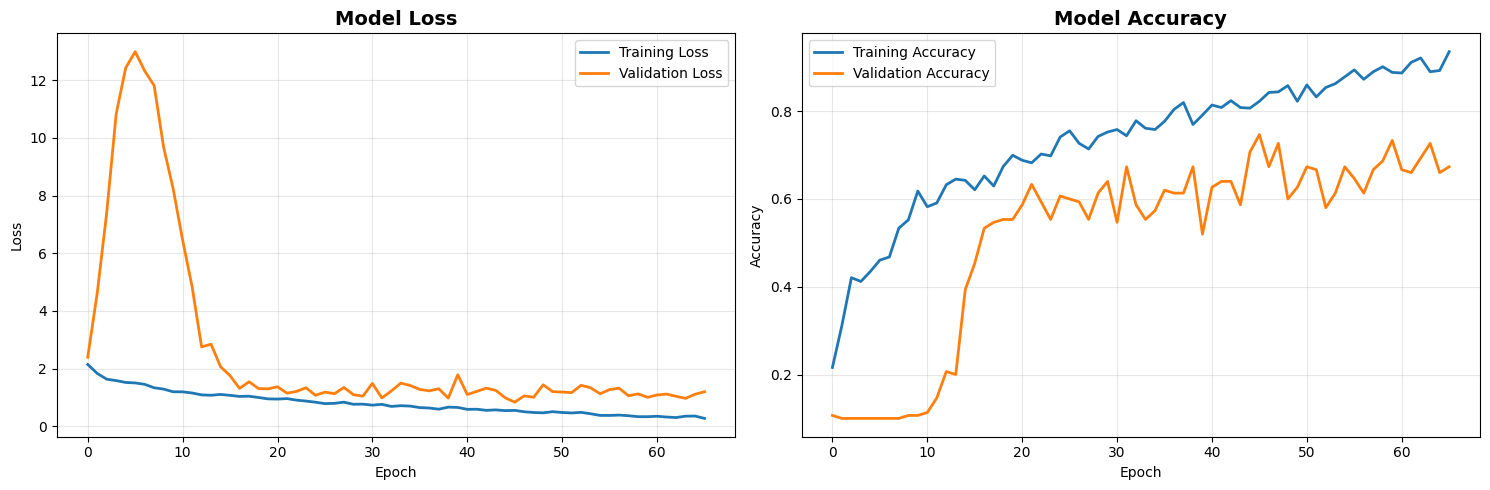


Final Results:
  Training Accuracy:   93.56%
  Validation Accuracy: 67.33%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nFinal Results:")
print(f"  Training Accuracy:   {history.history['accuracy'][-1]*100:.2f}%")
print(f"  Validation Accuracy: {history.history['val_accuracy'][-1]*100:.2f}%")

 Evaluating on test set...

Test Accuracy: 73.33%

Classification Report:
              precision    recall  f1-score   support

       blues       0.86      0.80      0.83        15
   classical       0.74      0.93      0.82        15
     country       0.64      0.47      0.54        15
       disco       0.86      0.40      0.55        15
      hiphop       0.79      1.00      0.88        15
        jazz       0.92      0.73      0.81        15
       metal       0.65      1.00      0.79        15
         pop       0.71      0.67      0.69        15
      reggae       1.00      0.67      0.80        15
        rock       0.48      0.67      0.56        15

    accuracy                           0.73       150
   macro avg       0.76      0.73      0.73       150
weighted avg       0.76      0.73      0.73       150



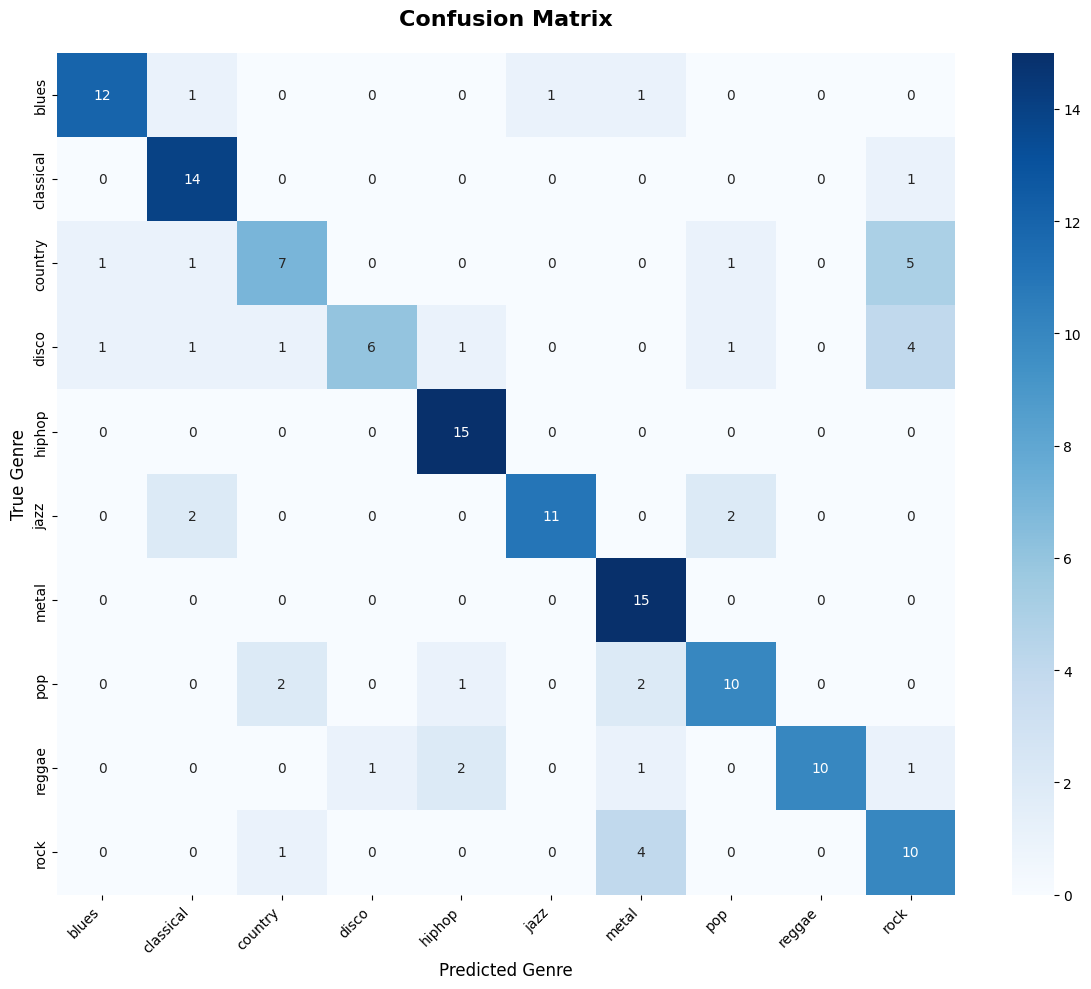

Per-Genre Accuracy:
  blues       : 80.00%
  classical   : 93.33%
  country     : 46.67%
  disco       : 40.00%
  hiphop      : 100.00%
  jazz        : 73.33%
  metal       : 100.00%
  pop         : 66.67%
  reggae      : 66.67%
  rock        : 66.67%


In [ ]:
print(" Evaluating on test set...\n")

# Predictions
y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# Accuracy
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_accuracy*100:.2f}%\n")

# Classification report

print("Classification Report:")

print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Genre', fontsize=12)
plt.xlabel('Predicted Genre', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Per-genre accuracy

print("Per-Genre Accuracy:")

for i, genre in enumerate(le.classes_):
    genre_mask = y_test == i
    genre_acc = accuracy_score(y_test[genre_mask], y_pred[genre_mask])
    print(f"  {genre:12s}: {genre_acc*100:.2f}%")


 Live Predictions:

✅ Sample 76:
   Actual:    jazz
   Predicted: jazz
   Confidence: 98.90%

✅ Sample 131:
   Actual:    reggae
   Predicted: reggae
   Confidence: 41.46%

✅ Sample 55:
   Actual:    disco
   Predicted: disco
   Confidence: 90.16%

✅ Sample 14:
   Actual:    jazz
   Predicted: jazz
   Confidence: 87.68%

✅ Sample 41:
   Actual:    country
   Predicted: country
   Confidence: 53.87%



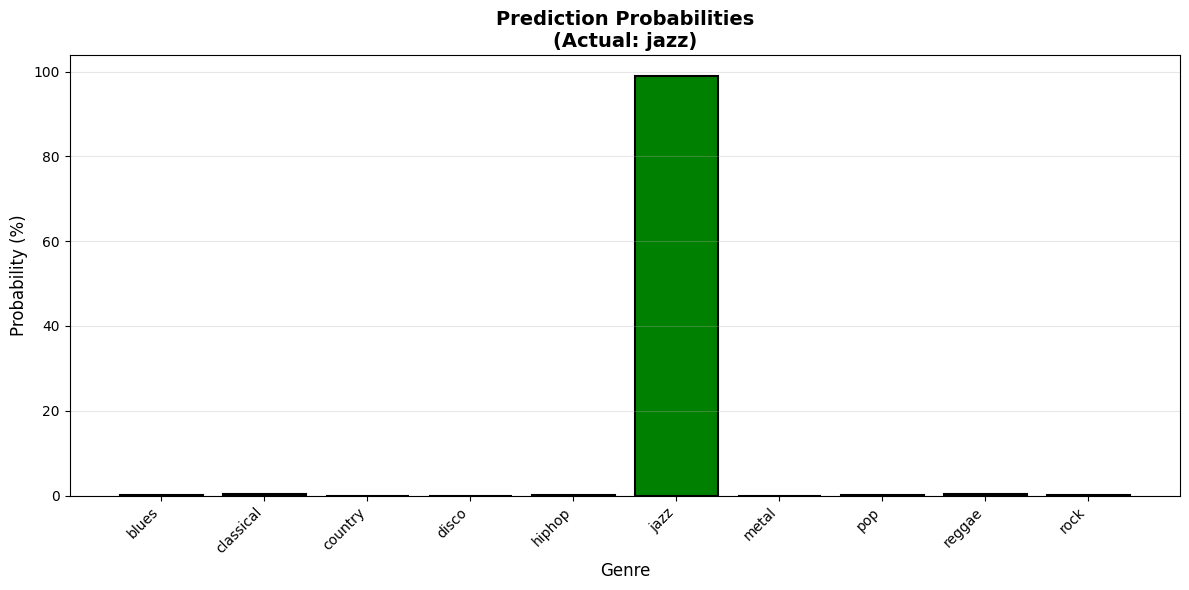

In [ ]:

print("\n Live Predictions:\n")

# Random samples
random_indices = np.random.choice(len(X_test), size=5, replace=False)

for idx in random_indices:
    actual = le.inverse_transform([y_test[idx]])[0]
    probabilities = model.predict(X_test[idx:idx+1], verbose=0)[0]
    predicted_class = np.argmax(probabilities)
    predicted = le.inverse_transform([predicted_class])[0]
    confidence = probabilities[predicted_class] * 100

    correct = "✅" if actual == predicted else "❌"
    print(f"{correct} Sample {idx}:")
    print(f"   Actual:    {actual}")
    print(f"   Predicted: {predicted}")
    print(f"   Confidence: {confidence:.2f}%\n")

# Visualize probabilities
sample_idx = random_indices[0]
probabilities = model.predict(X_test[sample_idx:sample_idx+1], verbose=0)[0]

plt.figure(figsize=(12, 6))
colors = ['green' if i == y_test[sample_idx] else 'skyblue'
          for i in range(len(GENRES))]
plt.bar(le.classes_, probabilities * 100, color=colors,
        edgecolor='black', linewidth=1.5)
plt.title(f'Prediction Probabilities\n(Actual: {le.inverse_transform([y_test[sample_idx]])[0]})',
          fontsize=14, fontweight='bold')
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Probability (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('prediction_probs.png', dpi=300, bbox_inches='tight')
plt.show()